# Exploratory Data Analysis (EDA)

EDA helps to understand the underlying patterns, relationships and distributions in the dataset. It's primary aim is to uncover underlying patterns, grasp dataset's structure and identify anomalies or relationship between variables.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
df = pd.read_csv('titanic_cleaned.csv')
df.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,1,0,3,22.0,1,0,7.2500,True,False,True
1,1,2,1,1,38.0,1,0,71.2833,False,False,False
2,2,3,1,3,26.0,0,0,7.9250,False,False,True
3,3,4,1,1,35.0,1,0,53.1000,False,False,True
4,4,5,0,3,35.0,0,0,8.0500,True,False,True


In [13]:
df.columns

Index(['Unnamed: 0', 'PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp',
       'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S'],
      dtype='str')

In [14]:
df = df.drop(columns= ['Unnamed: 0'])
df = df.set_index('PassengerId')
df.describe(include='all')

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891,891,891
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,True,False,True
freq,NaN,NaN,NaN,NaN,NaN,NaN,577,814,646
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208,NaN,NaN,NaN
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429,NaN,NaN,NaN
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,NaN,NaN,NaN
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN


In [15]:
df.shape

(891, 9)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB


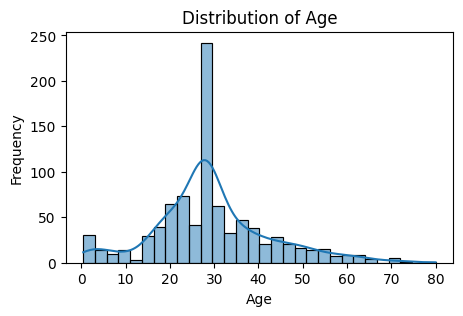

In [17]:
plt.figure(figsize=(5, 3))
sns.histplot(data=df['Age'], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

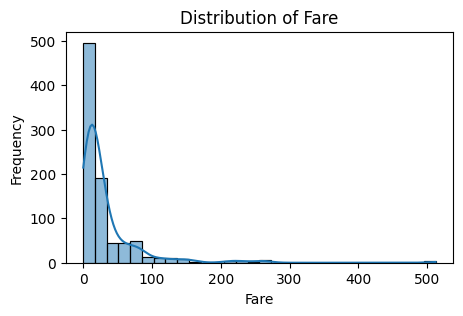

In [18]:
plt.figure(figsize=(5, 3))
sns.histplot(data=df["Fare"], bins=30, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

In [19]:
print("Skewness value of Fare: ", df["Fare"].skew())
print("Skewness value of Age: ", df["Age"].skew())

Skewness value of Fare:  4.787316519674893
Skewness value of Age:  0.5102446555756495


Skewness value of Fare:  0.3949280095189306


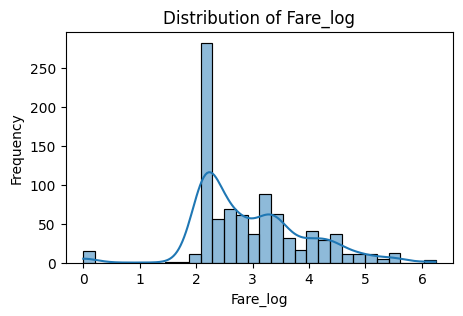

In [20]:
df["Fare_log"] = np.log1p(df["Fare"])
print("Skewness value of Fare: ", df["Fare_log"].skew())

plt.figure(figsize=(5, 3))
sns.histplot(data=df["Fare_log"], bins=30, kde=True)
plt.title("Distribution of Fare_log")
plt.xlabel("Fare_log")
plt.ylabel("Frequency")
plt.show()

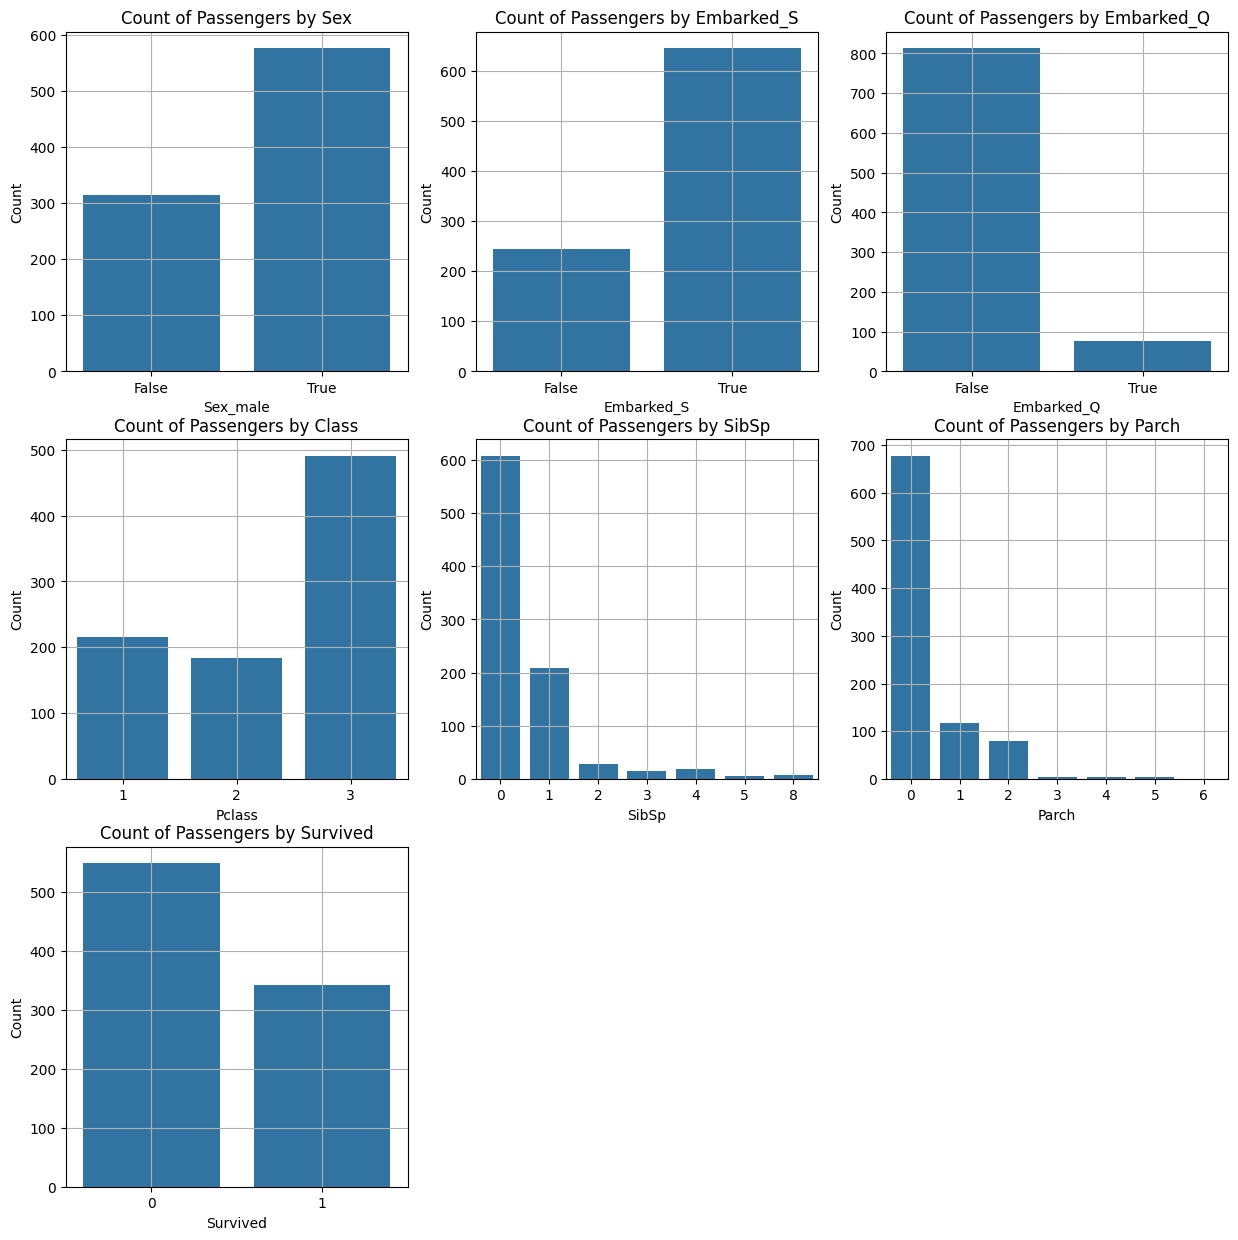

In [22]:
plt.figure(figsize=(15, 15))

plt.subplot(3, 3, 1)
sns.countplot(x='Sex_male', data=df)
plt.title("Count of Passengers by Sex")
plt.xlabel("Sex_male")
plt.ylabel("Count")
plt.grid(True)

plt.subplot(3, 3, 2)
sns.countplot(x="Embarked_S", data=df)
plt.title("Count of Passengers by Embarked_S")
plt.xlabel("Embarked_S")
plt.ylabel("Count")
plt.grid(True)

plt.subplot(3, 3, 3)
sns.countplot(x='Embarked_Q', data=df)
plt.title("Count of Passengers by Embarked_Q")
plt.xlabel("Embarked_Q")
plt.ylabel("Count")
plt.grid(True)

plt.subplot(3, 3, 4)
sns.countplot(x="Pclass", data=df)
plt.title("Count of Passengers by Class")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.grid(True)

plt.subplot(3, 3, 5)
sns.countplot(x="SibSp", data=df)
plt.title("Count of Passengers by SibSp")
plt.xlabel("SibSp")
plt.ylabel("Count")
plt.grid(True)

plt.subplot(3, 3, 6)
sns.countplot(x="Parch", data=df)
plt.title("Count of Passengers by Parch")
plt.xlabel("Parch")
plt.ylabel("Count")
plt.grid(True)

plt.subplot(3, 3, 7)
sns.countplot(x="Survived", data=df)
plt.title("Count of Passengers by Survived")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.grid(True)

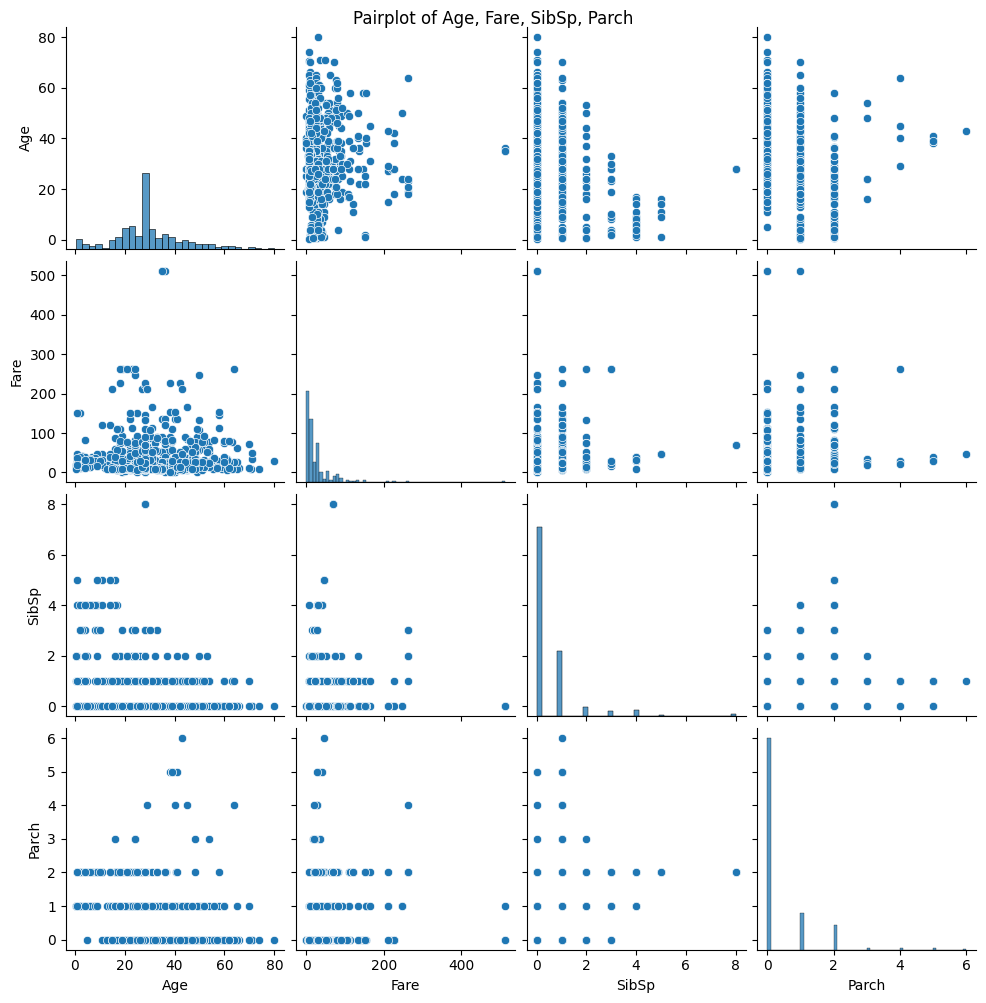

In [24]:
pairplot_columns = ["Age", "Fare", "SibSp", "Parch"]
sns.pairplot(df[pairplot_columns])
plt.suptitle("Pairplot of Age, Fare, SibSp, Parch", y=1.0)
plt.show()

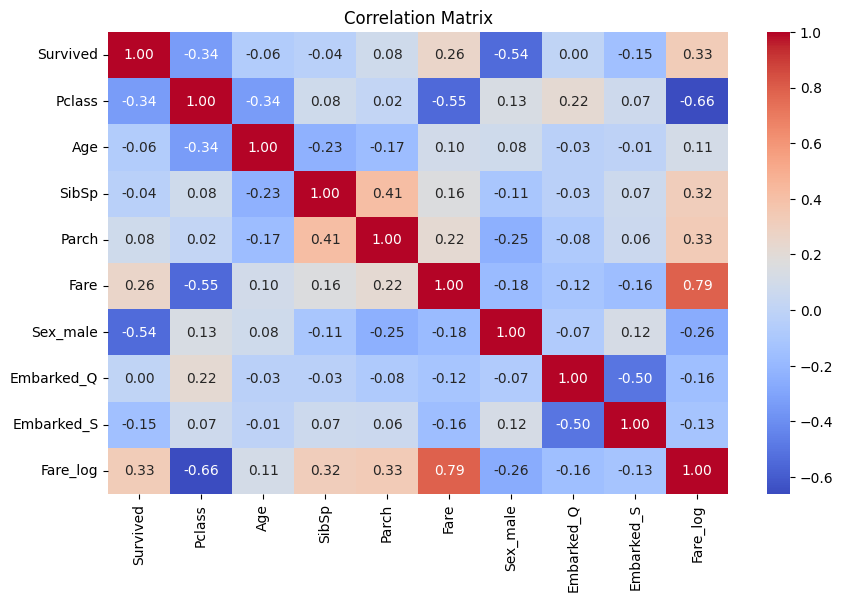

In [25]:
plt.figure(figsize=(10, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

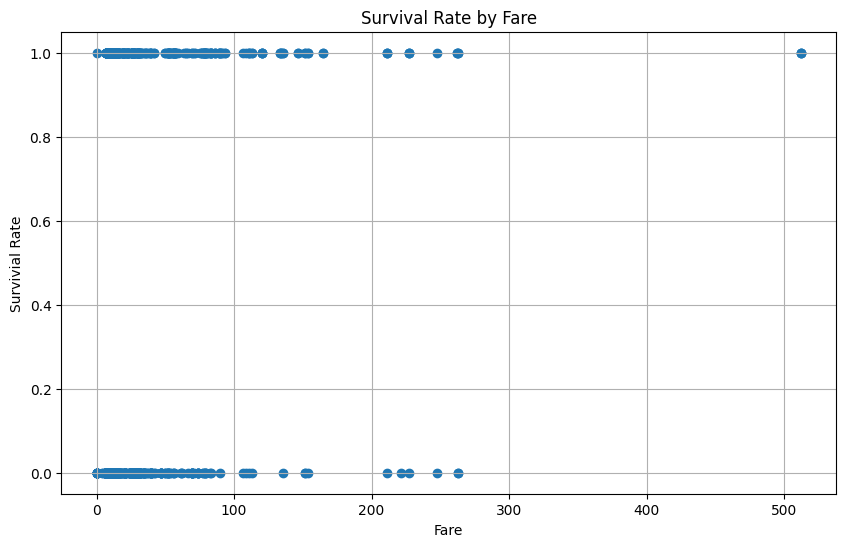

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Fare'], df['Survived'])
plt.title('Survival Rate by Fare')
plt.xlabel('Fare')
plt.ylabel('Survivial Rate')
plt.grid(True)
plt.show()

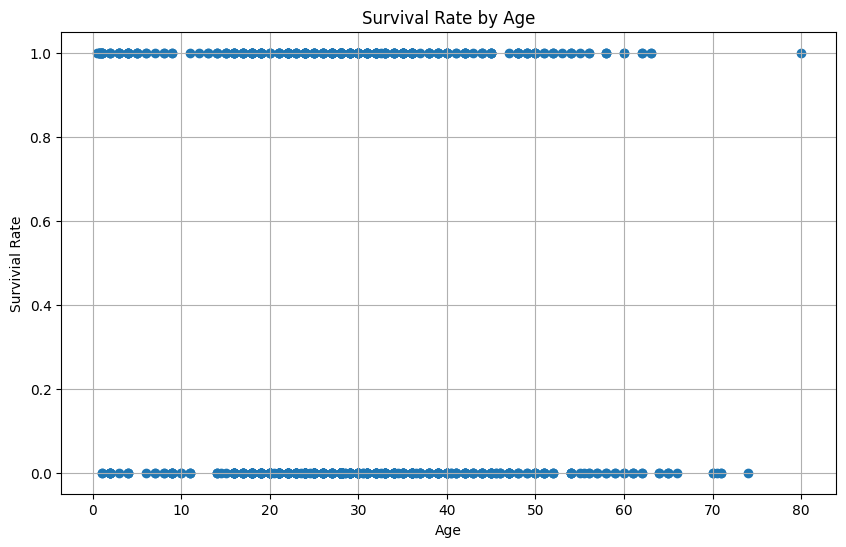

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Survived'])
plt.title('Survival Rate by Age')
plt.xlabel('Age')
plt.ylabel('Survivial Rate')
plt.grid(True)
plt.show()

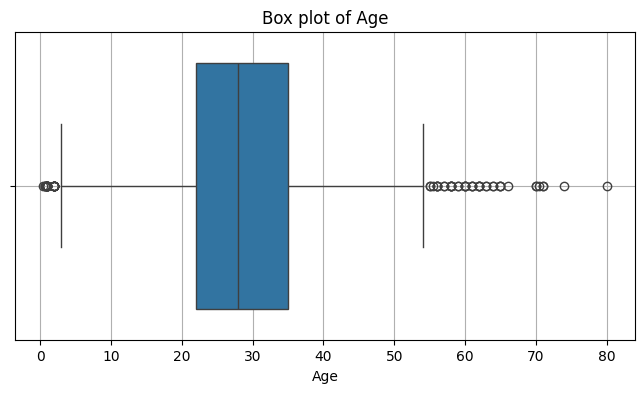

In [29]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Age'])
plt.title('Box plot of Age')
plt.xlabel('Age')
plt.grid()
plt.show()

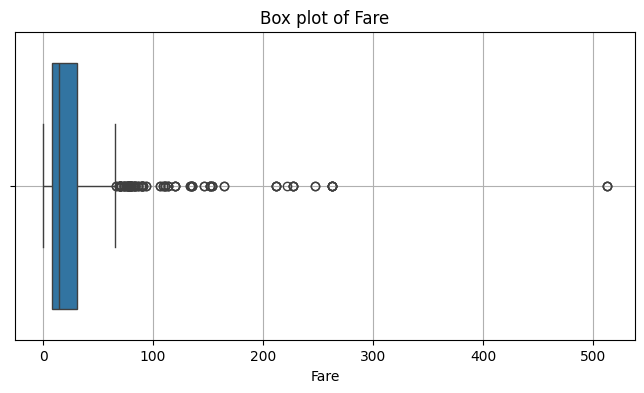

In [30]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Fare'])
plt.title('Box plot of Fare')
plt.xlabel('Fare')
plt.grid()
plt.show()

### Outliers treatment methods

Filtered data shape after outlier removal: (577, 10)


Text(0.5, 1.0, 'Boxplot of Fare Before outlier removal')

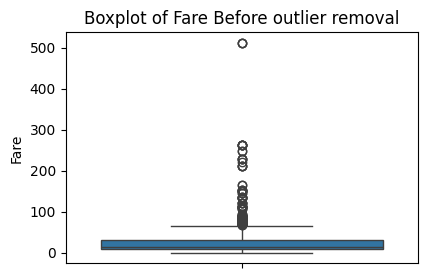

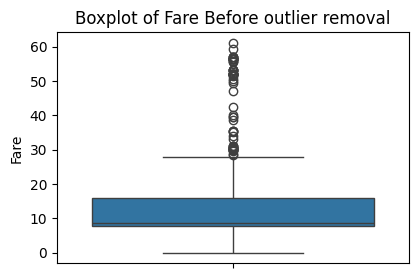

In [ ]:
# 1. removal of outliers

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df

columns_to_check = ['Age', 'Fare', 'SibSp', 'Parch']
filtered_df = df.copy()

for column in columns_to_check:
    filtered_df = remove_outliers(filtered_df, column)

print(f"Filtered data shape after outlier removal: {filtered_df.shape}")

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=df["Fare"])
plt.title("Boxplot of Fare Before outlier removal")

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=filtered_df["Fare"])
plt.title("Boxplot of Fare Before outlier removal")

Filtered data shape after capping outliers: (891, 10)


Text(0.5, 1.0, 'Boxplot of Fare Before capping outliers')

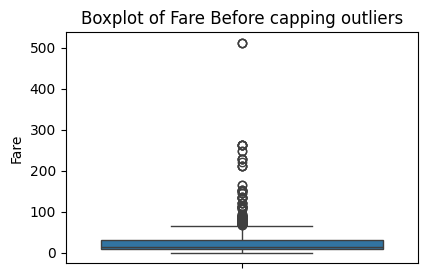

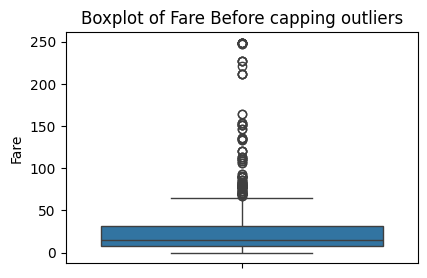

In [32]:
# 2. capping of outliers

def cap_outliers(df, column):
    lower_bound = df[column].quantile(0.01)
    upper_bound = df[column].quantile(0.99)
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

columns_to_check = ['Age', 'Fare', 'SibSp', 'Parch']
filtered_df = df.copy()

for column in columns_to_check:
    filtered_df = cap_outliers(filtered_df, column)

print(f"Filtered data shape after capping outliers: {filtered_df.shape}")

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=df["Fare"])
plt.title("Boxplot of Fare Before capping outliers")

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=filtered_df["Fare"])
plt.title("Boxplot of Fare Before capping outliers")

Text(0.5, 1.0, 'boxplot of Fare before transformation')

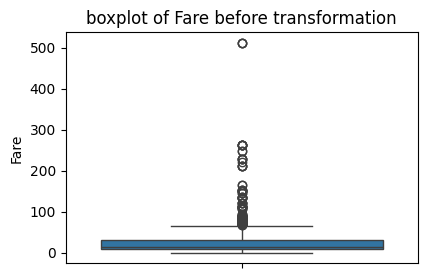

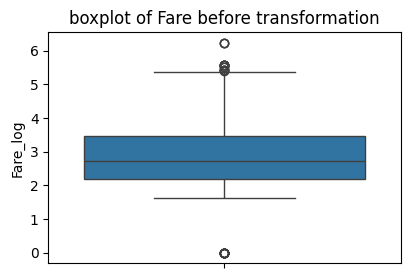

In [33]:
# 3. Log transformation

df['Fare_log'] = np.log1p(df['Fare'])

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=df["Fare"])
plt.title("boxplot of Fare before transformation")

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=df["Fare_log"])
plt.title("boxplot of Fare before transformation")

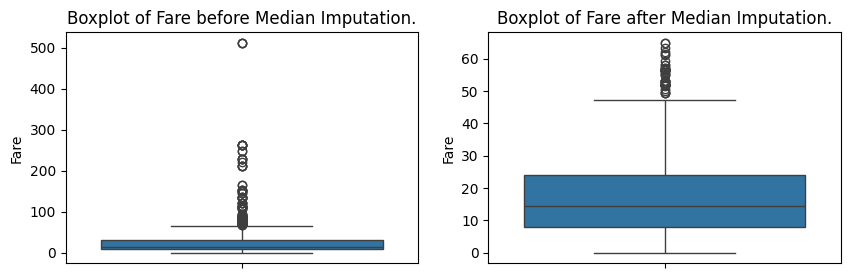

In [36]:
# 4. Median Imputation

def impute_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    median = df[column].median()
    df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound), median, df[column])
    return df


columns_to_check = ['Age', 'Fare', 'SibSp', 'Parch']
filtered_df = df.copy()

for column in columns_to_check:
    filtered_df = impute_outliers(filtered_df, column)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=df["Fare"])
plt.title("Boxplot of Fare before Median Imputation.")

plt.subplot(1, 2, 2)
sns.boxplot(data=filtered_df["Fare"])
plt.title("Boxplot of Fare after Median Imputation.")
plt.show()

Filtered Data Shape After Outlier Capping:  (820, 10)


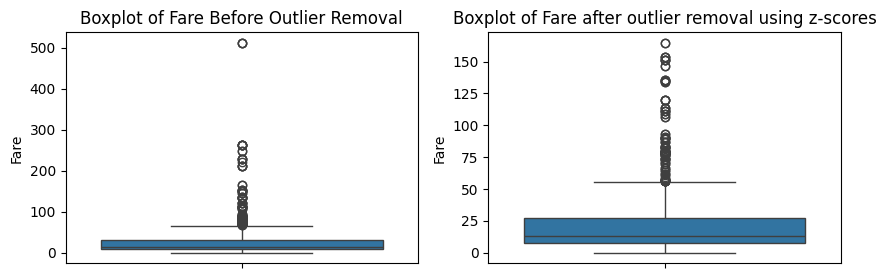

In [37]:
# 5. z-score method for outlier removal

def calculate_z_scores(df, column):
    mean = df[column].mean()
    std_dev = df[column].std()
    z_scores = ((df[column]-mean) / std_dev).abs()
    return z_scores

columns_to_check = ['Age', 'Fare', 'SibSp', 'Parch']
filtered_df = df.copy()
threshold = 3
for column in columns_to_check:
    z_scores = calculate_z_scores(filtered_df, column)
    filtered_df = filtered_df[z_scores < threshold]

print("Filtered Data Shape After Outlier Capping: ", filtered_df.shape)
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
sns.boxplot(data=df['Fare'])
plt.title("Boxplot of Fare Before Outlier Removal")

plt.subplot(1, 2, 2)
sns.boxplot(data=filtered_df["Fare"])
plt.title('Boxplot of Fare after outlier removal using z-scores')
plt.show()